<a href="https://colab.research.google.com/github/JYEmm-eng/DATATHON_6/blob/main/%EA%B0%80%EC%84%A4_%EB%A1%9C%EC%A7%80%EC%8A%A4%ED%8B%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/리뷰데이터/naver+google_review_final.csv")

In [ ]:
df

,내용,라벨
0,겸사겸사 에버랜드 다시 방문요😇😇 🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄 어머낫~아들이 좋아하...,1
1,키이스케이프와 콜라보한 방탈출이 있다고 해서 다녀왔는데 너무너무너무 재미있었습니다....,1
2,에버랜드 1박2일 가족 나들이~ 화창한 날씨가 아닌 흐리고 비도 오고 아쉬움이 많긴...,1
3,에버랜드에 오랜만에 갔어요^^ 오랜만에가니 새로워요 먹거리도 많고 볼거리 놀거리 진...,1
4,일요일 오후 5시에 방문하니 주차도 수월하고 놀이기구 대기 시간도 짧아 여유롭게 즐...,1
...,...,...
6555,장미축제 기간에 방문하였고 에버랜드에서 직접 접목하여 개발한 장미가 인상적이었습니다...,1
6556,언제가도 즐거운 환상의 나라 에버랜드 ~~\n계절마다 다른 꽃과 퍼레이드\n갈때마다...,1
6557,에버랜드 너무 좋아요😂…,1
6558,"한여름이라 덥지만, 오히려 사람이 적어 대기 시간이 짧아서 좋았음. 신나는 물 파티...",0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6560 entries, 0 to 6559
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   내용      6434 non-null   object
 1   라벨      6560 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 102.6+ KB


In [ ]:
%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

In [ ]:
df['라벨'].value_counts()

,count
라벨,
1,4373
0,2187


In [ ]:
# =========================
# 0) 기본 세팅 (Colab)
# =========================
!pip -q install pandas numpy scipy statsmodels

import pandas as pd
import numpy as np
import re
from scipy.stats import chi2_contingency
import statsmodels.api as sm


# =========================
# 1) 데이터 불러오기
# =========================
# 인코딩 자동 선택
encodings = ["utf-8-sig", "utf-8", "cp949"]
for enc in encodings:
    try:
        df = pd.read_csv(csv_name, encoding=enc)
        break
    except Exception:
        pass

# 컬럼명 표준화
df = df.rename(columns={"내용": "text", "라벨": "label"})
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(int)   # 1=긍정, 0=부정 가정

print(df.head(), df.shape)

# =========================
# 2) 가설별 키워드 사전
# =========================
kw_oper = [  # 운영/대기/혼잡
    "대기","줄","웨이팅","혼잡","예약","사전예약","우선권","시간지정","분산",
    "동선","운영","직원","배치","느리","지연","줄서","대기시간","긴줄","포화","밀집"
]
kw_content = [  # 콘텐츠/IP/행사
    "콘텐츠","컨텐츠","볼거리","공연","IP","아이피","한류","케이팝","K팝","K-pop",
    "드라마","판다","산리오","이벤트","체험","테마","캐릭터","쇼","즐길거리","볼거","티니핑","푸바오","러바오","아이바오",
]
kw_facility = [  # 시설/노후/청결
    "노후","낡","오래됨","시설","리모델링","보수","수리","관리","청결","위생",
    "부서","고장","깨끗","더럽","페인트","깨짐","녹","냄새","파손","누수","망가"
]

# 부분일치 정규식 탐색 함수
def has_any(text, keywords):
    return int(any(re.search(k, text) for k in keywords))

df["oper_flag"] = df["text"].apply(lambda x: has_any(x, kw_oper))
df["content_flag"] = df["text"].apply(lambda x: has_any(x, kw_content))
df["facility_flag"] = df["text"].apply(lambda x: has_any(x, kw_facility))

print(df[["text","label","oper_flag","content_flag","facility_flag"]].head())

# =========================
# 3) 교차표 & 카이제곱검정
# =========================
def chi_summary(flag_col):
    tab = pd.crosstab(df[flag_col], df["label"], dropna=False)
    for c in [0,1]:
        if c not in tab.columns: tab[c] = 0
    tab = tab[[0,1]]  # 열 순서 고정 (0=부정, 1=긍정)
    chi2, p, dof, exp = chi2_contingency(tab.values)
    return tab, chi2, p, dof

chi_results = []
for col in ["oper_flag","content_flag","facility_flag"]:
    tab, chi2, p, dof = chi_summary(col)
    print(f"\n=== {col} ===")
    print(tab)
    print(f"chi2={chi2:.3f}, p={p:.5f}, dof={dof}")
    chi_results.append([col, chi2, p, dof])

chi_df = pd.DataFrame(chi_results, columns=["flag","chi2","p_value","dof"])
display(chi_df)

# =========================
# 4) 로지스틱 회귀 (label ~ flags)
# =========================
X = df[["oper_flag","content_flag","facility_flag"]]
X = sm.add_constant(X)         # 절편
y = df["label"]

logit = sm.Logit(y, X, missing='drop').fit(disp=False)
print(logit.summary())

# 오즈비(= exp(coef)) 및 95% CI
params = logit.params
conf = logit.conf_int()
odds = np.exp(params)
odds_ci = np.exp(conf)

summary_table = pd.DataFrame({
    "coef": params.round(3),
    "odds_ratio": odds.round(3),
    "ci_low": odds_ci[0].round(3),
    "ci_high": odds_ci[1].round(3),
    "p_value": logit.pvalues.round(5)
})
display(summary_table)

# 해석 도움말
print(
    "\n[해석]\n"
    "- 오즈비 < 1 : 해당 요인 언급 시 '긍정(=1)' 확률이 낮아지는 경향(부정 방향)\n"
    "- 오즈비 > 1 : 해당 요인 언급 시 '긍정(=1)' 확률이 높아지는 경향(긍정 방향)\n"
    "- p_value < 0.05 : 통계적으로 유의함"
)

# =========================
# 5) 결과 저장 & 다운로드
# =========================
chi_df.to_csv("chi_square_summary.csv", index=False, encoding="utf-8-sig")
summary_table.to_csv("logistic_regression_summary.csv", encoding="utf-8-sig")

print("\n생성된 파일:")
print("- chi_square_summary.csv")
print("- logistic_regression_summary.csv")



                                                text  label  oper_flag  \
0  겸사겸사 에버랜드 다시 방문요😇😇 🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄 어머낫~아들이 좋아하...      1          1   
1  키이스케이프와 콜라보한 방탈출이 있다고 해서 다녀왔는데 너무너무너무 재미있었습니다....      1          0   
2  에버랜드 1박2일 가족 나들이~ 화창한 날씨가 아닌 흐리고 비도 오고 아쉬움이 많긴...      1          1   
3  에버랜드에 오랜만에 갔어요^^ 오랜만에가니 새로워요 먹거리도 많고 볼거리 놀거리 진...      1          0   
4  일요일 오후 5시에 방문하니 주차도 수월하고 놀이기구 대기 시간도 짧아 여유롭게 즐...      1          1   

   content_flag  facility_flag  
0             1              0  
1             1              0  
2             0              0  
3             1              1  
4             0              0   (6560, 5)
                                                text  label  oper_flag  \
0  겸사겸사 에버랜드 다시 방문요😇😇 🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄🥬🍄 어머낫~아들이 좋아하...      1          1   
1  키이스케이프와 콜라보한 방탈출이 있다고 해서 다녀왔는데 너무너무너무 재미있었습니다....      1          0   
2  에버랜드 1박2일 가족 나들이~ 화창한 날씨가 아닌 흐리고 비도 오고 아쉬움이 많긴...      1          1   
3  에버랜드에 오랜만에 갔어요^^ 오랜만에가니 새로워요 먹거리도 많고 볼거리 놀거리 진..

,flag,chi2,p_value,dof
0,oper_flag,153.297739,3.297637e-35,1
1,content_flag,1.955169,1.620309e-01,1
2,facility_flag,99.873597,1.624404e-23,1


                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                 6560
Model:                          Logit   Df Residuals:                     6556
Method:                           MLE   Df Model:                            3
Date:                Wed, 12 Nov 2025   Pseudo R-squ.:                 0.02789
Time:                        06:29:13   Log-Likelihood:                -4059.3
converged:                       True   LL-Null:                       -4175.8
Covariance Type:            nonrobust   LLR p-value:                 3.263e-50
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.9118      0.034     27.198      0.000       0.846       0.978
oper_flag        -0.7036      0.060    -11.691      0.000      -0.822      -0.586
content_flag      0.1909      0.074     

,coef,odds_ratio,ci_low,ci_high,p_value
const,0.912,2.489,2.331,2.658,0.00000
oper_flag,-0.704,0.495,0.440,0.557,0.00000
content_flag,0.191,1.210,1.046,1.400,0.01021
facility_flag,-0.882,0.414,0.341,0.503,0.00000



[해석]
- 오즈비 < 1 : 해당 요인 언급 시 '긍정(=1)' 확률이 낮아지는 경향(부정 방향)
- 오즈비 > 1 : 해당 요인 언급 시 '긍정(=1)' 확률이 높아지는 경향(긍정 방향)
- p_value < 0.05 : 통계적으로 유의함

생성된 파일:
- chi_square_summary.csv
- logistic_regression_summary.csv


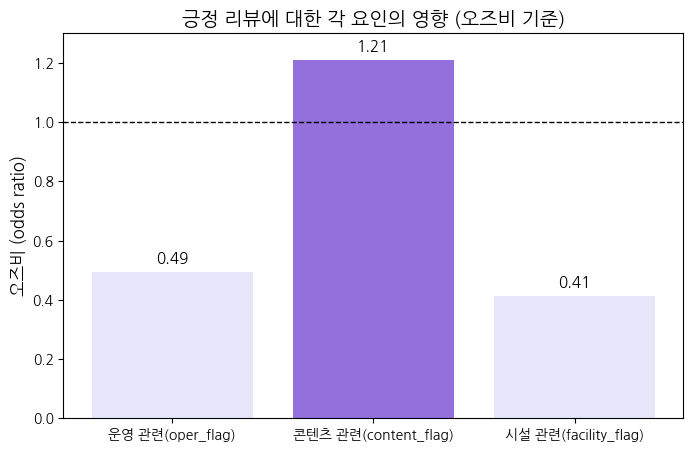

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 데이터프레임 생성
df_plot = pd.DataFrame({
    "변수": ["운영 관련(oper_flag)", "콘텐츠 관련(content_flag)", "시설 관련(facility_flag)"],
    "오즈비": [0.4950, 1.210, 0.414],
    "p_value": [0.000, 0.010, 0.000]
})

# 색상: p<0.05면 빨간색(유의), 아니면 회색
colors = ["#E6E6FA" if 오즈비 < 1 else "#9370DB" for 오즈비 in df_plot["오즈비"]]

plt.figure(figsize=(8,5))
bars = plt.bar(df_plot["변수"], df_plot["오즈비"], color=colors)
plt.axhline(1, color="black", linestyle="--", linewidth=1)
plt.title("긍정 리뷰에 대한 각 요인의 영향 (오즈비 기준)", fontsize=14)
plt.ylabel("오즈비 (odds ratio)", fontsize=12)

# 값 표시
for bar, val in zip(bars, df_plot["오즈비"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.03, f"{val:.2f}", ha='center', fontsize=11)

plt.ylim(0, 1.3)
plt.show()


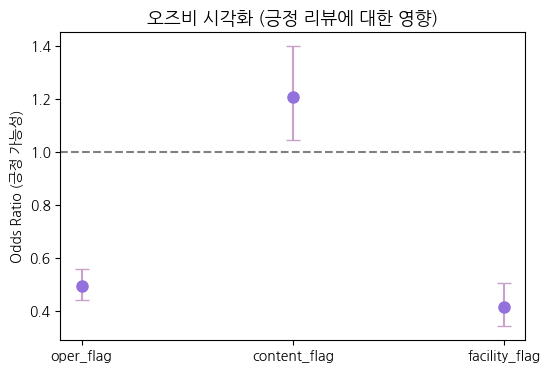

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 결과 요약
data = {
    'Variable': ['oper_flag', 'content_flag', 'facility_flag'],
    'Odds Ratio': [0.495, 1.210, 0.414],
    'CI Low': [0.440, 1.046, 0.341],
    'CI High': [0.557, 1.400, 0.503]
}
df = pd.DataFrame(data)

# 그래프
plt.figure(figsize=(6,4))
plt.errorbar(df['Variable'], df['Odds Ratio'],
             yerr=[df['Odds Ratio']-df['CI Low'], df['CI High']-df['Odds Ratio']],
             fmt='o', color='#9370DB', ecolor='#C8A2C8', capsize=5, markersize=8)
plt.axhline(y=1, color='gray', linestyle='--')
plt.title('오즈비 시각화 (긍정 리뷰에 대한 영향)', fontsize=13)
plt.ylabel('Odds Ratio (긍정 가능성)')
plt.show()
